In [1]:
# ==========================================
# PHASE 1: KERNEL SVM (7 vs Not 7)
# SETUP & IMPORTS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# Scikit-Learn (Data Handling, Modeling, and Evaluation)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Scikit-Image (Image Processing and Feature Extraction)
from skimage.feature import hog
from skimage.transform import resize

# Set a random seed so your results are reproducible!
np.random.seed(42)

# Set default plotting style for images
plt.rc('image', cmap='gray')

print("Environment setup complete. All libraries imported!")

Environment setup complete. All libraries imported!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# 1. Download MNIST
print("Downloading MNIST dataset...")

X, y = fetch_openml(
    'mnist_784',
    version=1,
    return_X_y=True,
    as_frame=False,
    parser='auto'
)

# Convert labels to integers
y = y.astype(np.int32)

print(f"Total images loaded: {X.shape[0]}")
print(f"Pixels per image: {X.shape[1]} (28x28 flattened image)")
print(f"Classes: {np.unique(y)}")

Total images loaded: 70000
Pixels per image: 784 (28x28 flattened image)
Classes: [0 1 2 3 4 5 6 7 8 9]


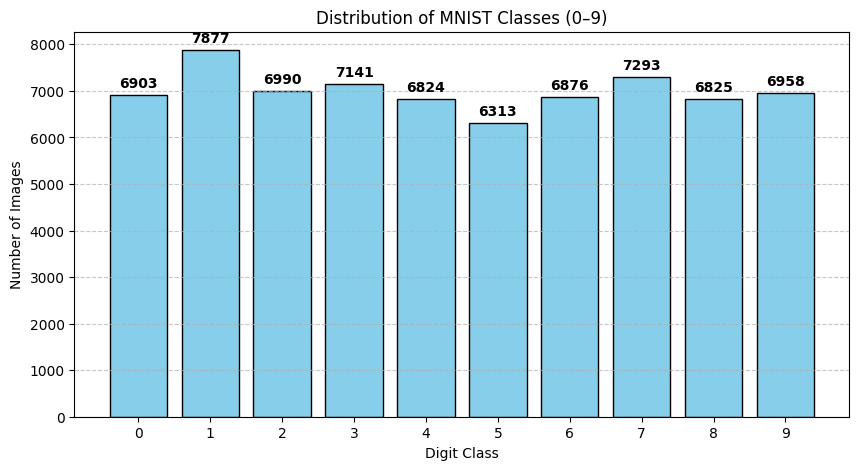


Class Distribution:
Digit 0: 6903 images (9.86%)
Digit 1: 7877 images (11.25%)
Digit 2: 6990 images (9.99%)
Digit 3: 7141 images (10.20%)
Digit 4: 6824 images (9.75%)
Digit 5: 6313 images (9.02%)
Digit 6: 6876 images (9.82%)
Digit 7: 7293 images (10.42%)
Digit 8: 6825 images (9.75%)
Digit 9: 6958 images (9.94%)


In [3]:
# ==========================================
# CHECKING CLASS DISTRIBUTION
# ==========================================

# Count samples in each digit class
unique_classes, class_counts = np.unique(y, return_counts=True)

# Create bar chart
plt.figure(figsize=(10, 5))

bars = plt.bar(
    unique_classes,
    class_counts,
    color='skyblue',
    edgecolor='black'
)

# Add count labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 100,
        f'{yval}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.title('Distribution of MNIST Classes (0–9)')
plt.xlabel('Digit Class')
plt.ylabel('Number of Images')
plt.xticks(unique_classes)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Print exact counts
print("\nClass Distribution:")
for cls, count in zip(unique_classes, class_counts):
    percentage = (count / len(y)) * 100
    print(f"Digit {cls}: {count} images ({percentage:.2f}%)")

In [4]:
from sklearn.model_selection import train_test_split

# ==========================================
# DATA SPLITTING
# ==========================================

# 1. MASTER SPLIT
# 80% for Train/Validation Pool
# 20% reserved for Final Testing

X_train_val_pool, X_final_test, y_train_val_pool, y_final_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# OPTIONAL SUBSETTING
# ==========================================

# Use a smaller subset for faster experimentation
subset_size = 5000

subset_ratio = subset_size / len(X_train_val_pool)

X_subset, _, y_subset, _ = train_test_split(
    X_train_val_pool,
    y_train_val_pool,
    train_size=subset_ratio,
    random_state=42,
    stratify=y_train_val_pool
)

# ==========================================
# TRAIN / VALIDATION SPLIT
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=0.25,
    random_state=42,
    stratify=y_subset
)

# ==========================================
# SUMMARY
# ==========================================

print("\n--- Data Integrity Check ---")

print(f"Training Set:      {len(X_train)} samples")
print(f"Validation Set:    {len(X_val)} samples")
print(f"Final Test Set:    {len(X_final_test)} samples")

print("\nClass Distribution in Training Set:")

unique_classes, class_counts = np.unique(y_train, return_counts=True)

for cls, count in zip(unique_classes, class_counts):
    percentage = (count / len(y_train)) * 100
    print(f"Digit {cls}: {count} samples ({percentage:.2f}%)")


--- Data Integrity Check ---
Training Set:      3750 samples
Validation Set:    1250 samples
Final Test Set:    14000 samples

Class Distribution in Training Set:
Digit 0: 370 samples (9.87%)
Digit 1: 422 samples (11.25%)
Digit 2: 374 samples (9.97%)
Digit 3: 383 samples (10.21%)
Digit 4: 365 samples (9.73%)
Digit 5: 338 samples (9.01%)
Digit 6: 368 samples (9.81%)
Digit 7: 391 samples (10.43%)
Digit 8: 366 samples (9.76%)
Digit 9: 373 samples (9.95%)


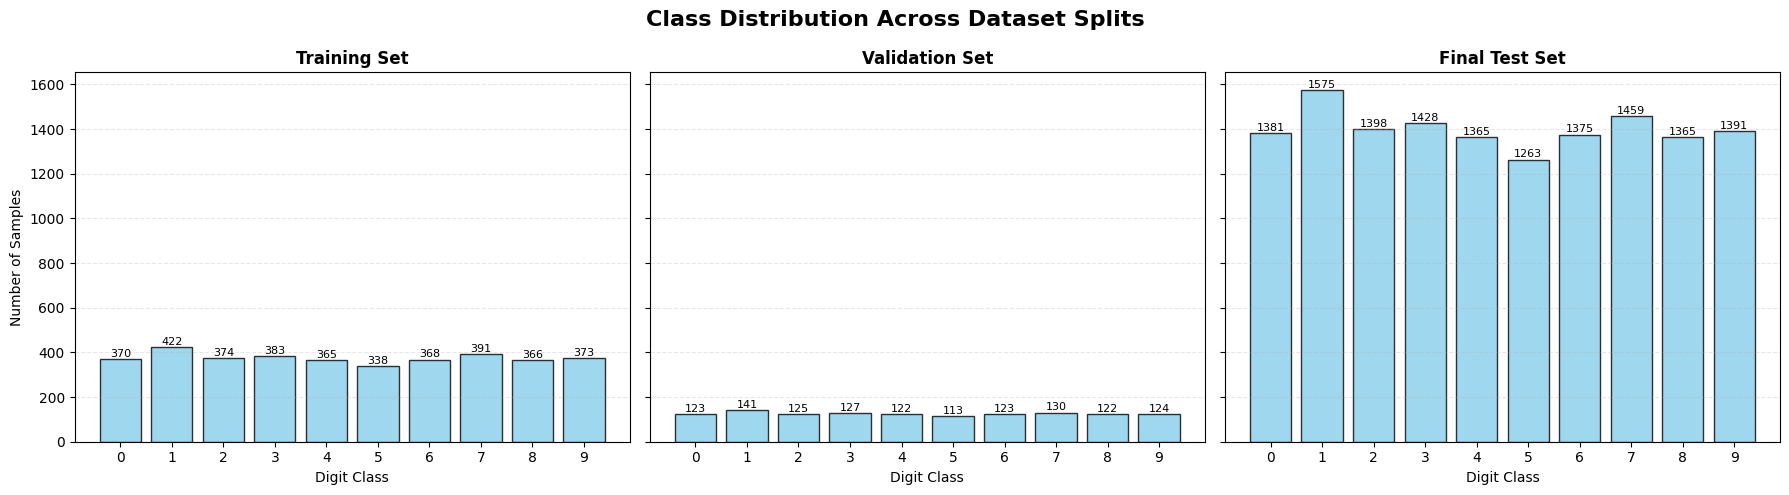

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# CHECK STRATIFICATION INTEGRITY
# ==========================================

sets = {
    'Training': y_train,
    'Validation': y_val,
    'Final Test': y_final_test
}

classes = np.arange(10)

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fig.suptitle(
    'Class Distribution Across Dataset Splits',
    fontsize=16,
    fontweight='bold'
)

# ==========================================
# PLOT EACH DATASET SPLIT
# ==========================================

for ax, (set_name, labels) in zip(axes, sets.items()):

    class_counts = [np.sum(labels == cls) for cls in classes]

    bars = ax.bar(
        classes,
        class_counts,
        color='skyblue',
        edgecolor='black',
        alpha=0.8
    )

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 10,
            f'{height}',
            ha='center',
            fontsize=8
        )

    ax.set_title(f'{set_name} Set', fontweight='bold')
    ax.set_xlabel('Digit Class')
    ax.set_xticks(classes)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[0].set_ylabel('Number of Samples')

plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# PHASE 2: FEATURE ENGINEERING
# HOG Feature Extraction (28x28 MNIST)
# ==========================================

from skimage.feature import hog
from skimage import exposure
import matplotlib.pyplot as plt
import numpy as np

def process_hog_pipeline(X_data, name="Dataset"):
    """
    Reshape flattened MNIST images and extract HOG descriptors.
    """

    print(f"Extracting HOG features for {name} ({len(X_data)} samples)...")

    hog_features = []

    for i in range(len(X_data)):

        # Reshape 784 -> 28x28
        img_2d = X_data[i].reshape(28, 28)

        # Extract HOG descriptor
        fd = hog(
            img_2d,
            orientations=9,
            pixels_per_cell=(7, 7),
            cells_per_block=(2, 2),
            visualize=False
        )

        hog_features.append(fd)

    return np.array(hog_features)

# ==========================================
# EXECUTE FEATURE EXTRACTION
# ==========================================

X_train_hog = process_hog_pipeline(X_train, "Training Set")
X_val_hog   = process_hog_pipeline(X_val, "Validation Set")
X_test_hog  = process_hog_pipeline(X_final_test, "Final Test Set")

print("\nHOG Extraction Complete!")

print(f"Original Feature Count: {X_train.shape[1]} pixels")
print(f"HOG Feature Count:      {X_train_hog.shape[1]} features")

Extracting HOG features for Training Set (3750 samples)...
Extracting HOG features for Validation Set (1250 samples)...
Extracting HOG features for Final Test Set (14000 samples)...

HOG Extraction Complete!
Original Feature Count: 784 pixels
HOG Feature Count:      324 features


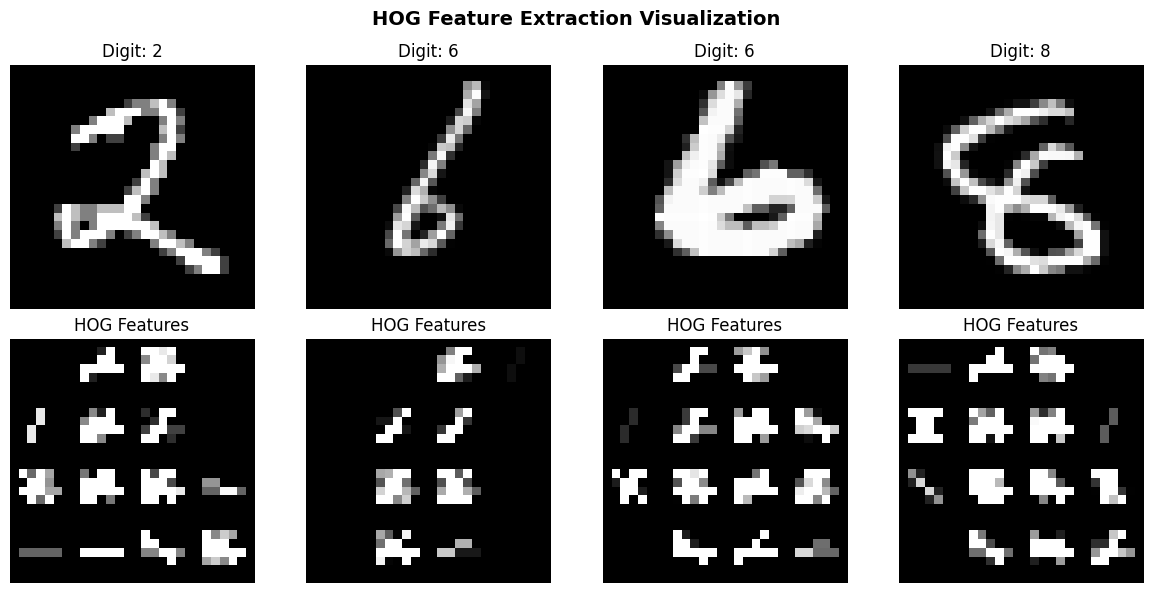

In [7]:
# ==========================================
# HOG VISUALIZATION CHECK
# ==========================================

# Random example digits
demo_indices = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, idx in enumerate(demo_indices):

    img = X_train[idx].reshape(28, 28)

    # Generate HOG visualization
    fd, hog_viz = hog(
        img,
        orientations=9,
        pixels_per_cell=(7, 7),
        cells_per_block=(2, 2),
        visualize=True
    )

    # Improve visualization contrast
    hog_viz_rescaled = exposure.rescale_intensity(
        hog_viz,
        in_range=(0, 10)
    )

    # Original image
    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Digit: {y_train[idx]}")
    axes[0, i].axis('off')

    # HOG visualization
    axes[1, i].imshow(hog_viz_rescaled, cmap='gray')
    axes[1, i].set_title("HOG Features")
    axes[1, i].axis('off')

plt.suptitle("HOG Feature Extraction Visualization", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [16]:
# ==========================================
# PHASE 2: FEATURE SCALING
# Manual StandardScaler Normalization
# ==========================================

import numpy as np

print("Initializing Manual StandardScaler...")

# ==========================================
# COMPUTE TRAINING STATISTICS ONLY
# ==========================================
# Prevents data leakage.
# Learn mean/std ONLY from training data.

train_mean = np.mean(
    X_train_hog,
    axis=0
)

train_std = np.std(
    X_train_hog,
    axis=0
)

# ==========================================
# AVOID DIVISION BY ZERO
# ==========================================

train_std[train_std == 0] = 1

# ==========================================
# MANUAL STANDARDIZATION
# ==========================================
# Formula:
# z = (x - mean) / std

X_train_scaled = (
    X_train_hog - train_mean
) / train_std

X_val_scaled = (
    X_val_hog - train_mean
) / train_std

X_test_scaled = (
    X_test_hog - train_mean
) / train_std

print("Feature Scaling Complete!")

# ==========================================
# SCALING SANITY CHECK
# ==========================================

print("\n--- Scaling Sanity Check ---")

print(
    f"Training Mean (≈0): "
    f"{X_train_scaled.mean():.17f}"
)

print(
    f"Training Std  (≈1): "
    f"{X_train_scaled.std():.6f}"
)

print(
    f"\nValidation Mean:    "
    f"{X_val_scaled.mean():.6f}"
)

print(
    f"Validation Std:     "
    f"{X_val_scaled.std():.6f}"
)

print(
    f"\nTest Mean:          "
    f"{X_test_scaled.mean():.6f}"
)

print(
    f"Test Std:           "
    f"{X_test_scaled.std():.6f}"
)

Initializing Manual StandardScaler...
Feature Scaling Complete!

--- Scaling Sanity Check ---
Training Mean (≈0): -0.00000000000000018
Training Std  (≈1): 1.000000

Validation Mean:    0.000318
Validation Std:     1.002341

Test Mean:          -0.000850
Test Std:           0.996764


In [9]:
!pip install qpsolvers

import numpy as np
from scipy.spatial.distance import cdist
from qpsolvers import solve_qp

# ==========================================
# PHASE 2: MANUAL BINARY SVM
# (Used inside One-vs-All multiclass system)
# ==========================================

class ManualBinarySVM:

    def __init__(self, C=1.0, gamma='scale'):

        self.C = C
        self.gamma = gamma

        self.alpha = None
        self.b = 0

    # ==========================================
    # COMPUTE GAMMA
    # ==========================================

    def _compute_gamma(self, X):

        if self.gamma == 'scale':
            self.gamma_value = 1 / (X.shape[1] * np.var(X))
        else:
            self.gamma_value = self.gamma

        return self.gamma_value

    # ==========================================
    # RBF KERNEL
    # ==========================================

    def rbf_kernel(self, X1, X2):

        gamma = self.gamma_value

        sq_dists = cdist(X1, X2, 'sqeuclidean')

        return np.exp(-gamma * sq_dists)

    # ==========================================
    # TRAIN BINARY SVM
    # ==========================================

    def fit(self, X, y):

        print(f"Training Binary SVM on {len(X)} samples...")

        n = len(y)

        # Compute gamma once
        self._compute_gamma(X)

        # Kernel matrix
        K = self.rbf_kernel(X, X)

        # ==========================================
        # BUILD QP MATRICES
        # ==========================================

        Y = y.reshape(-1, 1) * y.reshape(1, -1)

        P = K * Y + np.eye(n) * 1e-8

        q = -np.ones(n)

        A = y.astype(float)

        b = np.array([0.0])

        lb = np.zeros(n)

        ub = np.ones(n) * self.C

        # ==========================================
        # SOLVE QP
        # ==========================================

        self.alpha = solve_qp(
            P,
            q,
            A=A,
            b=b,
            lb=lb,
            ub=ub,
            solver="osqp"
        )

        if self.alpha is None:
            raise ValueError("QP Solver Failed")

        # ==========================================
        # SUPPORT VECTORS
        # ==========================================

        sv_mask = self.alpha > 1e-6

        self.alpha_sv = self.alpha[sv_mask]

        self.X_sv = X[sv_mask]

        self.y_sv = y[sv_mask]

        # ==========================================
        # COMPUTE BIAS TERM
        # ==========================================

        margin_mask = (
            (self.alpha > 1e-6) &
            (self.alpha < self.C - 1e-6)
        )

        b_sum = 0
        count = 0

        for i in range(n):

            if margin_mask[i]:

                K_i = self.rbf_kernel(
                    X,
                    X[i].reshape(1, -1)
                ).flatten()

                pred = np.sum(self.alpha * y * K_i)

                b_sum += y[i] - pred

                count += 1

        # Fallback if no margin SV found
        if count == 0:

            for i in range(len(self.alpha_sv)):

                K_i = self.rbf_kernel(
                    self.X_sv,
                    self.X_sv[i].reshape(1, -1)
                ).flatten()

                pred = np.sum(
                    self.alpha_sv * self.y_sv * K_i
                )

                b_sum += self.y_sv[i] - pred

            self.b = b_sum / len(self.alpha_sv)

        else:
            self.b = b_sum / count

        print(f"Support Vectors: {len(self.alpha_sv)}")
        print(f"Bias b: {self.b:.4f}")

    # ==========================================
    # DECISION FUNCTION
    # IMPORTANT FOR ONE-vs-ALL
    # ==========================================

    def decision_function(self, X):

        K = self.rbf_kernel(self.X_sv, X)

        decision = (
            np.dot(self.alpha_sv * self.y_sv, K)
            + self.b
        )

        return decision

    # ==========================================
    # BINARY PREDICTION
    # ==========================================

    def predict(self, X):

        decision = self.decision_function(X)

        return np.sign(decision)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.8/106.8 kB 3.9 MB/s eta 0:00:00


In [10]:
# ==========================================
# PHASE 2: ONE-vs-ALL MULTICLASS SVM
# ==========================================

class OneVsAllSVM:

    def __init__(self, C=1.0, gamma='scale'):

        self.C = C
        self.gamma = gamma

        self.models = {}

    # ==========================================
    # TRAIN 10 BINARY CLASSIFIERS
    # ==========================================

    def fit(self, X, y):

        self.classes = np.unique(y)

        print("\nTraining One-vs-All SVM System...\n")

        for cls in self.classes:

            print(f"\n========== DIGIT {cls} vs ALL ==========")

            # Convert to binary labels
            binary_y = np.where(y == cls, 1, -1)

            # Train binary classifier
            model = ManualBinarySVM(
                C=self.C,
                gamma=self.gamma
            )

            model.fit(X, binary_y)

            self.models[cls] = model

        print("\nAll classifiers trained successfully!")

    # ==========================================
    # MULTICLASS PREDICTION
    # ==========================================

    def predict(self, X):

        scores = []

        # Get decision score from each classifier
        for cls in self.classes:

            score = self.models[cls].decision_function(X)

            scores.append(score)

        # Shape:
        # (n_classes, n_samples)
        scores = np.array(scores)

        # Choose class with highest score
        predictions = self.classes[np.argmax(scores, axis=0)]

        return predictions

Starting One-vs-All Training...


Training One-vs-All SVM System...


========== DIGIT 0 vs ALL ==========
Training Binary SVM on 3750 samples...


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 412
Bias b: -0.9367

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 389
Bias b: -0.8661

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 626
Bias b: -0.3712

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 938
Bias b: -0.8061

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 691
Bias b: -0.7462

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 617
Bias b: -0.6858

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 388
Bias b: -0.8484

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 653
Bias b: -0.7144

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 548
Bias b: -1.4448

========== DIGIT 9 vs ALL ==========
Training Bina

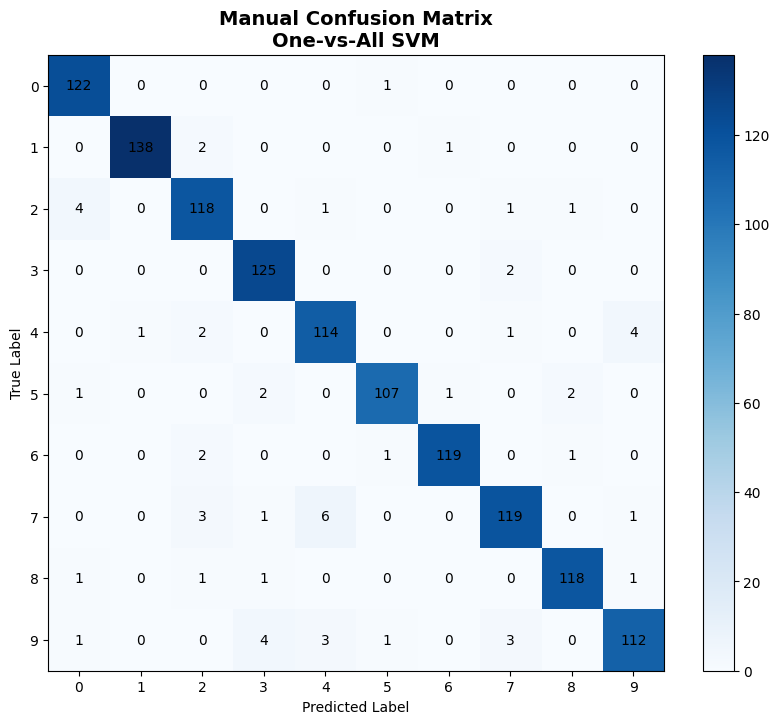

In [11]:
# ==========================================
# STEP 6: BASELINE MULTICLASS SVM
# TRAINING + VALIDATION
# MANUAL EVALUATION METRICS
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# INITIALIZE MODEL
# ==========================================

ova_svm = OneVsAllSVM(
    C=1.0,
    gamma='scale'
)

# ==========================================
# TRAIN MODEL
# ==========================================

print("Starting One-vs-All Training...\n")

ova_svm.fit(X_train_scaled, y_train)

print("\nTraining Complete!")

# ==========================================
# VALIDATION PREDICTION
# ==========================================

print("\nPredicting Validation Set...")

y_val_pred = ova_svm.predict(X_val_scaled)

# ==========================================
# MANUAL ACCURACY
# ==========================================

accuracy = np.mean(y_val_pred == y_val)

print("\n========================================")
print("VALIDATION RESULTS")
print("========================================")

print(f"\nValidation Accuracy: {accuracy:.4f}")

# ==========================================
# MANUAL CONFUSION MATRIX
# ==========================================

classes = np.unique(y_val)

num_classes = len(classes)

conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_val, y_val_pred):

    conf_matrix[true_label][pred_label] += 1

# ==========================================
# MANUAL PRECISION / RECALL / F1
# ==========================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================\n")

print(f"{'Class':<10}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")

precisions = []
recalls = []
f1_scores = []

for cls in classes:

    TP = conf_matrix[cls, cls]

    FP = np.sum(conf_matrix[:, cls]) - TP

    FN = np.sum(conf_matrix[cls, :]) - TP

    # Precision
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)

    # Recall
    if TP + FN == 0:
        recall = 0
    else:
        recall = TP / (TP + FN)

    # F1 Score
    if precision + recall == 0:
        f1 = 0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

    print(f"{cls:<10}{precision:<12.4f}{recall:<12.4f}{f1:<12.4f}")

# ==========================================
# MACRO AVERAGES
# ==========================================

macro_precision = np.mean(precisions)

macro_recall = np.mean(recalls)

macro_f1 = np.mean(f1_scores)

print("\n========================================")
print("MACRO AVERAGES")
print("========================================")

print(f"Precision: {macro_precision:.4f}")

print(f"Recall:    {macro_recall:.4f}")

print(f"F1-Score:  {macro_f1:.4f}")

# ==========================================
# DISPLAY CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(10, 8))

plt.imshow(conf_matrix, cmap='Blues')

plt.title(
    'Manual Confusion Matrix\nOne-vs-All SVM',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Label')

plt.ylabel('True Label')

plt.xticks(classes)

plt.yticks(classes)

# Add numbers inside matrix
for i in range(num_classes):

    for j in range(num_classes):

        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.colorbar()

plt.show()

In [12]:
# ==========================================
# STEP 7: HYPERPARAMETER TUNING
# WITH CROSS-VALIDATION
# MANUAL METRICS
# ==========================================

from sklearn.model_selection import StratifiedKFold
import pandas as pd
import numpy as np

# ==========================================
# PARAMETER GRID
# ==========================================

C_values = [0.1, 1, 10]

gamma_values = ['scale', 0.01]

# ==========================================
# CROSS-VALIDATION SETUP
# ==========================================

skf = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# ==========================================
# STORE RESULTS
# ==========================================

results = []

best_accuracy = 0

best_params = None

best_model = None

# ==========================================
# GRID SEARCH + CROSS-VALIDATION
# ==========================================

for C in C_values:

    for gamma in gamma_values:

        print("\n========================================")
        print(f"Testing Parameters: C={C}, gamma={gamma}")
        print("========================================")

        fold_accuracies = []

        # ==========================================
        # CROSS-VALIDATION LOOP
        # ==========================================

        for fold, (train_idx, val_idx) in enumerate(
            skf.split(X_train_scaled, y_train)
        ):

            print(f"\n--- Fold {fold+1}/3 ---")

            # ==========================================
            # SPLIT DATA
            # ==========================================

            X_fold_train = X_train_scaled[train_idx]

            y_fold_train = y_train[train_idx]

            X_fold_val = X_train_scaled[val_idx]

            y_fold_val = y_train[val_idx]

            # ==========================================
            # CREATE MODEL
            # ==========================================

            model = OneVsAllSVM(
                C=C,
                gamma=gamma
            )

            # ==========================================
            # TRAIN MODEL
            # ==========================================

            model.fit(X_fold_train, y_fold_train)

            # ==========================================
            # VALIDATION PREDICTIONS
            # ==========================================

            y_pred = model.predict(X_fold_val)

            # ==========================================
            # MANUAL ACCURACY
            # ==========================================

            accuracy = np.mean(y_pred == y_fold_val)

            fold_accuracies.append(accuracy)

            print(f"Fold Accuracy: {accuracy:.4f}")

        # ==========================================
        # MEAN CV RESULTS
        # ==========================================

        mean_accuracy = np.mean(fold_accuracies)

        std_accuracy = np.std(fold_accuracies)

        print("\nCV Results:")

        print(f"Mean Accuracy: {mean_accuracy:.4f}")

        print(f"Std Accuracy:  {std_accuracy:.4f}")

        # ==========================================
        # STORE RESULTS
        # ==========================================

        results.append({
            'C': C,
            'gamma': gamma,
            'mean_cv_accuracy': mean_accuracy,
            'std_cv_accuracy': std_accuracy
        })

        # ==========================================
        # TRACK BEST MODEL
        # ==========================================

        if mean_accuracy > best_accuracy:

            best_accuracy = mean_accuracy

            best_params = {
                'C': C,
                'gamma': gamma
            }

# ==========================================
# RESULTS TABLE
# ==========================================

results_df = pd.DataFrame(results)

print("\n========================================")
print("GRID SEARCH RESULTS")
print("========================================")

print(results_df)

# ==========================================
# BEST PARAMETERS
# ==========================================

print("\n========================================")
print("BEST PARAMETERS")
print("========================================")

print(f"Best C: {best_params['C']}")

print(f"Best Gamma: {best_params['gamma']}")

print(f"Best Mean CV Accuracy: {best_accuracy:.4f}")

# ==========================================
# TRAIN FINAL BEST MODEL
# ==========================================

print("\nTraining Final Best Model on Full Training Set...")

best_model = OneVsAllSVM(
    C=best_params['C'],
    gamma=best_params['gamma']
)

best_model.fit(X_train_scaled, y_train)

print("\nBest model training complete!")


Testing Parameters: C=0.1, gamma=scale

--- Fold 1/3 ---

Training One-vs-All SVM System...


========== DIGIT 0 vs ALL ==========
Training Binary SVM on 2500 samples...


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 499
Bias b: -0.8156

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 487
Bias b: -0.7384

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 578
Bias b: -0.2012

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 643
Bias b: -0.6219

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 588
Bias b: -0.4349

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 567
Bias b: -0.4228

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 471
Bias b: -0.8796

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 562
Bias b: -0.5930

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 545
Bias b: -0.9582

========== DIGIT 9 vs ALL ==========
Training Bina

/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 1337
Bias b: -0.9775

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1200
Bias b: -0.9504

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 2168
Bias b: -0.9479

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1804
Bias b: -0.9755

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1415
Bias b: -0.9766

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 2300
Bias b: -0.9628

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 2292
Bias b: -0.9618

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 2482
Bias b: -0.9486

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1916
Bias b: -0.9766

========== DIGIT 9 vs ALL ==========
Trai

...

Support Vectors: 332
Bias b: -0.9447

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 257
Bias b: -0.7693

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 522
Bias b: -0.3593

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 706
Bias b: -0.8428

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 459
Bias b: -0.7730

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 494
Bias b: -0.6333

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 286
Bias b: -0.8697

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 506
Bias b: -0.7059

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 447
Bias b: -1.4450

========== DIGIT 9 vs ALL ==========
Training Bina

/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 1379
Bias b: -0.8692

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1282
Bias b: -0.8895

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1490
Bias b: -0.5092

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1666
Bias b: -0.7628

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1544
Bias b: -0.7464

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1491
Bias b: -0.7479

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1329
Bias b: -0.8812

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1489
Bias b: -0.7249

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 2500 samples...
Support Vectors: 1517
Bias b: -0.9072

========== DIGIT 9 vs ALL ==========
Trai

/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 409
Bias b: -1.0161

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 320
Bias b: -0.7778

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 627
Bias b: -0.3550

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 860
Bias b: -0.8279

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 607
Bias b: -0.7486

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 638
Bias b: -0.6462

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 367
Bias b: -0.8603

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 678
Bias b: -0.6558

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 661
Bias b: -1.4864

========== DIGIT 9 vs ALL ==========
Training Bina


Training Model with C = 0.01

Training One-vs-All SVM System...


========== DIGIT 0 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3424
Bias b: -0.7587

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3422
Bias b: -0.8775

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 1295
Bias b: -0.9085

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3601
Bias b: -0.9584

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3567
Bias b: -0.9611

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3570
Bias b: -0.9444

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3588
Bias b: -0.9589

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 3750 samples...
Support Vectors: 3618
Bias b: -0.9211

========== DI

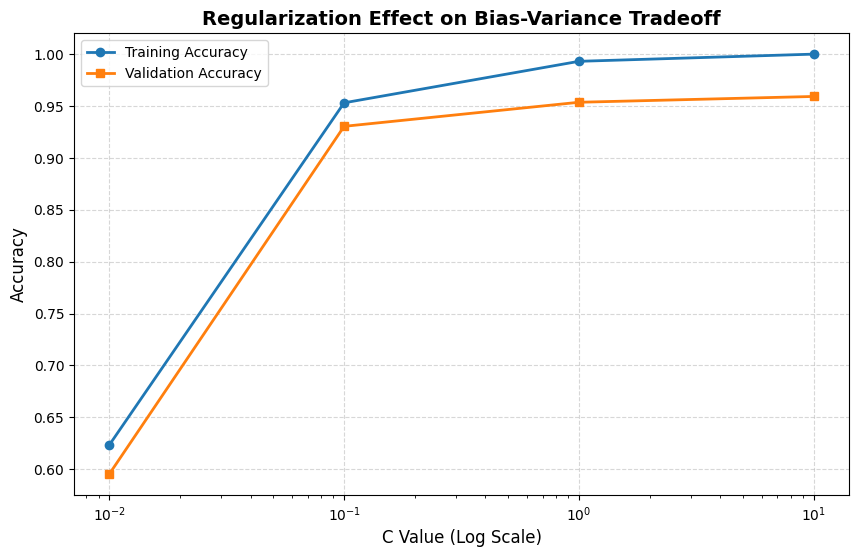


BIAS-VARIANCE INTERPRETATION

Best Validation Performance achieved at C = 10

Interpretation:
- Small C values apply stronger regularization,
  which may cause underfitting (high bias).

- Large C values reduce regularization,
  allowing the model to fit training data more closely,
  which may increase overfitting (high variance).

- The gap between training and validation accuracy
  indicates the bias-variance tradeoff.



In [13]:
# ==========================================
# STEP 8: REGULARIZATION & BIAS-VARIANCE ANALYSIS
# MANUAL METRICS
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ==========================================
# REGULARIZATION VALUES
# ==========================================

# Small C  -> Strong regularization
# Large C  -> Weak regularization

C_values = [0.01, 0.1, 1, 10]

# Use best gamma from Step 7
gamma_value = best_params['gamma']

# ==========================================
# STORE RESULTS
# ==========================================

train_accuracies = []

val_accuracies = []

results = []

# ==========================================
# TRAIN MODELS WITH DIFFERENT C VALUES
# ==========================================

for C in C_values:

    print("\n========================================")
    print(f"Training Model with C = {C}")
    print("========================================")

    # ==========================================
    # CREATE MODEL
    # ==========================================

    model = OneVsAllSVM(
        C=C,
        gamma=gamma_value
    )

    # ==========================================
    # TRAIN MODEL
    # ==========================================

    model.fit(X_train_scaled, y_train)

    # ==========================================
    # TRAINING PREDICTIONS
    # ==========================================

    y_train_pred = model.predict(X_train_scaled)

    # ==========================================
    # VALIDATION PREDICTIONS
    # ==========================================

    y_val_pred = model.predict(X_val_scaled)

    # ==========================================
    # MANUAL ACCURACY CALCULATION
    # ==========================================

    train_acc = np.mean(y_train_pred == y_train)

    val_acc = np.mean(y_val_pred == y_val)

    # ==========================================
    # STORE RESULTS
    # ==========================================

    train_accuracies.append(train_acc)

    val_accuracies.append(val_acc)

    results.append({
        'C': C,
        'Train Accuracy': train_acc,
        'Validation Accuracy': val_acc
    })

    print(f"Training Accuracy:   {train_acc:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")

# ==========================================
# RESULTS TABLE
# ==========================================

results_df = pd.DataFrame(results)

print("\n========================================")
print("BIAS-VARIANCE RESULTS")
print("========================================")

print(results_df)

# ==========================================
# PLOT TRAIN VS VALIDATION ACCURACY
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    C_values,
    train_accuracies,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    C_values,
    val_accuracies,
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xscale('log')

plt.xlabel('C Value (Log Scale)', fontsize=12)

plt.ylabel('Accuracy', fontsize=12)

plt.title(
    'Regularization Effect on Bias-Variance Tradeoff',
    fontsize=14,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

# ==========================================
# INTERPRETATION
# ==========================================

best_index = np.argmax(val_accuracies)

best_C = C_values[best_index]

print("\n========================================")
print("BIAS-VARIANCE INTERPRETATION")
print("========================================")

print(f"\nBest Validation Performance achieved at C = {best_C}")

print("""
Interpretation:
- Small C values apply stronger regularization,
  which may cause underfitting (high bias).

- Large C values reduce regularization,
  allowing the model to fit training data more closely,
  which may increase overfitting (high variance).

- The gap between training and validation accuracy
  indicates the bias-variance tradeoff.
""")


Training with 10% of Training Data
Training Samples: 375

Training One-vs-All SVM System...


========== DIGIT 0 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 134
Bias b: -0.9158

========== DIGIT 1 vs ALL ==========
Training Binary SVM on 375 samples...


/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'P' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/qpsolvers/conversions/ensure_sparse_matrices.py:28: SparseConversionWarning: Converted matrix 'A' of your problem to scipy.sparse.csc_matrix to pass it to solver 'osqp'; for best performance, build your matrix as a csc_matrix directly.
  warnings.warn(


Support Vectors: 119
Bias b: -0.6604

========== DIGIT 2 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 151
Bias b: -0.2974

========== DIGIT 3 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 159
Bias b: -1.0503

========== DIGIT 4 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 129
Bias b: -0.9698

========== DIGIT 5 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 154
Bias b: -0.7457

========== DIGIT 6 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 122
Bias b: -0.9409

========== DIGIT 7 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 147
Bias b: -0.7014

========== DIGIT 8 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 139
Bias b: -1.0537

========== DIGIT 9 vs ALL ==========
Training Binary SVM on 375 samples...
Support Vectors: 127
Bias b: -1.0209

All classifiers trained successfully!
Training Accuracy:  

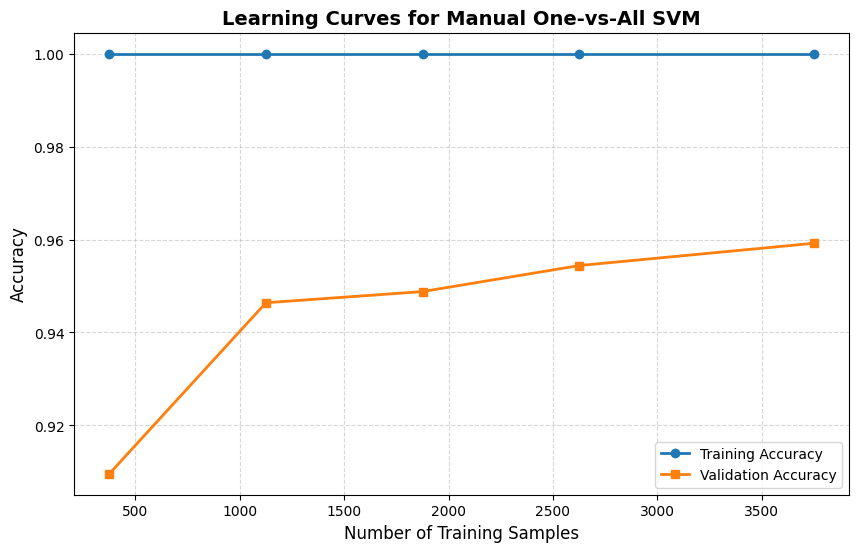


LEARNING CURVE INTERPRETATION

Final Training Accuracy:   1.0000
Final Validation Accuracy: 0.9592
Final Gap: 0.0408

Interpretation:
- Large gap between training and validation accuracy
  suggests overfitting (high variance).

- Low training and validation accuracy together
  suggest underfitting (high bias).

- High and converging accuracies indicate
  good generalization performance.



In [14]:
# ==========================================
# STEP 9: LEARNING CURVES
# OVERFITTING / UNDERFITTING DIAGNOSIS
# MANUAL METRICS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# TRAINING SET FRACTIONS
# ==========================================

train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]

# ==========================================
# STORE RESULTS
# ==========================================

training_accuracies = []

validation_accuracies = []

sample_counts = []

# ==========================================
# USE BEST PARAMETERS FROM STEP 7
# ==========================================

best_C = best_params['C']

best_gamma = best_params['gamma']

# ==========================================
# LEARNING CURVE LOOP
# ==========================================

for frac in train_sizes:

    print("\n========================================")
    print(f"Training with {int(frac*100)}% of Training Data")
    print("========================================")

    # ==========================================
    # SUBSET SIZE
    # ==========================================

    subset_size = int(len(X_train_scaled) * frac)

    sample_counts.append(subset_size)

    # Use first N samples
    X_subset = X_train_scaled[:subset_size]

    y_subset = y_train[:subset_size]

    print(f"Training Samples: {subset_size}")

    # ==========================================
    # CREATE MODEL
    # ==========================================

    model = OneVsAllSVM(
        C=best_C,
        gamma=best_gamma
    )

    # ==========================================
    # TRAIN MODEL
    # ==========================================

    model.fit(X_subset, y_subset)

    # ==========================================
    # TRAINING PREDICTIONS
    # ==========================================

    y_train_pred = model.predict(X_subset)

    # ==========================================
    # VALIDATION PREDICTIONS
    # ==========================================

    y_val_pred = model.predict(X_val_scaled)

    # ==========================================
    # MANUAL ACCURACY CALCULATION
    # ==========================================

    train_acc = np.mean(y_train_pred == y_subset)

    val_acc = np.mean(y_val_pred == y_val)

    # ==========================================
    # STORE RESULTS
    # ==========================================

    training_accuracies.append(train_acc)

    validation_accuracies.append(val_acc)

    print(f"Training Accuracy:   {train_acc:.4f}")

    print(f"Validation Accuracy: {val_acc:.4f}")

# ==========================================
# PLOT LEARNING CURVES
# ==========================================

plt.figure(figsize=(10, 6))

plt.plot(
    sample_counts,
    training_accuracies,
    marker='o',
    linewidth=2,
    label='Training Accuracy'
)

plt.plot(
    sample_counts,
    validation_accuracies,
    marker='s',
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Number of Training Samples', fontsize=12)

plt.ylabel('Accuracy', fontsize=12)

plt.title(
    'Learning Curves for Manual One-vs-All SVM',
    fontsize=14,
    fontweight='bold'
)

plt.grid(True, linestyle='--', alpha=0.5)

plt.legend()

plt.show()

# ==========================================
# OVERFITTING / UNDERFITTING ANALYSIS
# ==========================================

final_gap = (
    training_accuracies[-1]
    - validation_accuracies[-1]
)

print("\n========================================")
print("LEARNING CURVE INTERPRETATION")
print("========================================")

print(f"\nFinal Training Accuracy:   {training_accuracies[-1]:.4f}")

print(f"Final Validation Accuracy: {validation_accuracies[-1]:.4f}")

print(f"Final Gap: {final_gap:.4f}")

print("""
Interpretation:
- Large gap between training and validation accuracy
  suggests overfitting (high variance).

- Low training and validation accuracy together
  suggest underfitting (high bias).

- High and converging accuracies indicate
  good generalization performance.
""")

FINAL TEST EVALUATION

Using Best Parameters:
C = 10
Gamma = scale

Predicting Final Test Set...

Final Test Accuracy: 0.9636

CLASSIFICATION REPORT

Class     Precision   Recall      F1-Score    
0         0.9722      0.9884      0.9803      
1         0.9840      0.9765      0.9802      
2         0.9595      0.9657      0.9626      
3         0.9440      0.9678      0.9557      
4         0.9567      0.9560      0.9564      
5         0.9736      0.9620      0.9677      
6         0.9818      0.9818      0.9818      
7         0.9576      0.9452      0.9514      
8         0.9655      0.9421      0.9537      
9         0.9408      0.9490      0.9449      

MACRO AVERAGES
Precision: 0.9636
Recall:    0.9634
F1-Score:  0.9635


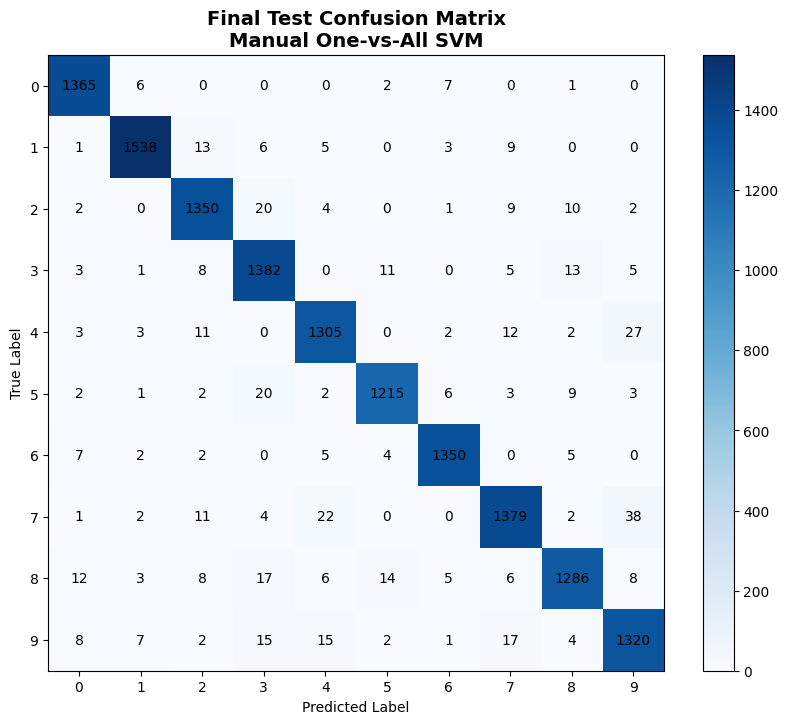


Total Misclassified Images: 510


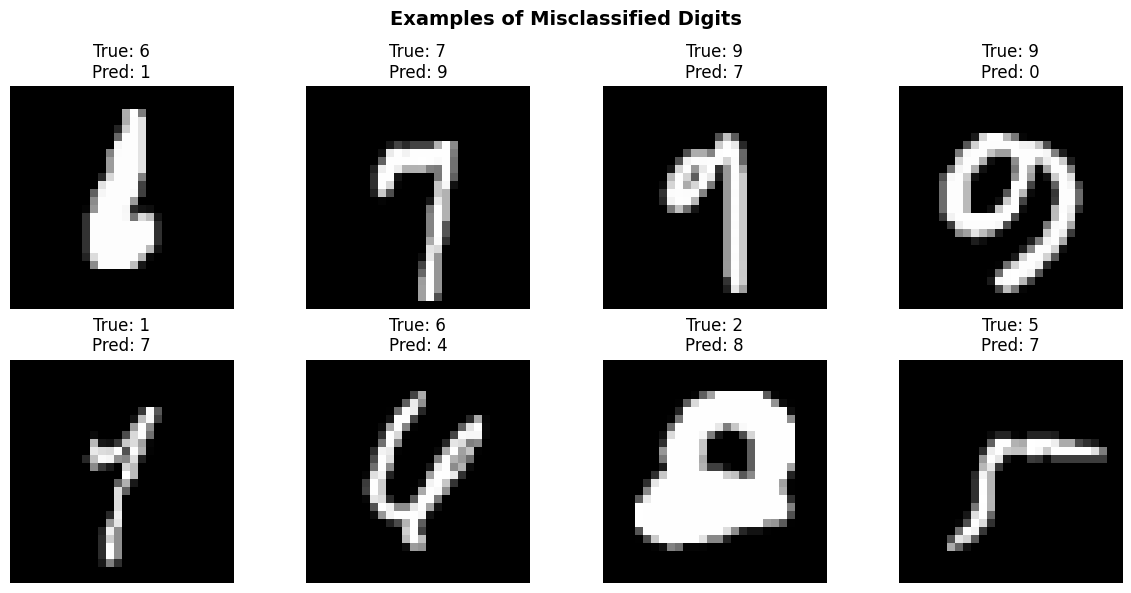


FINAL MODEL SUMMARY

Model Type:
Manual One-vs-All SVM with RBF Kernel

Feature Engineering:
HOG Features

Hyperparameter Tuning:
Manual Grid Search with 3-Fold Cross-Validation

Regularization:
L2-style soft-margin regularization using C parameter

Final Test Accuracy:
0.9636



In [15]:
# ==========================================
# STEP 10: FINAL TEST EVALUATION
# MANUAL METRICS
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# USE BEST MODEL FROM STEP 7
# ==========================================

print("========================================")
print("FINAL TEST EVALUATION")
print("========================================")

print("\nUsing Best Parameters:")

print(f"C = {best_params['C']}")

print(f"Gamma = {best_params['gamma']}")

# ==========================================
# TEST SET PREDICTION
# ==========================================

print("\nPredicting Final Test Set...")

y_test_pred = best_model.predict(X_test_scaled)

# ==========================================
# MANUAL ACCURACY
# ==========================================

test_accuracy = np.mean(y_test_pred == y_final_test)

print(f"\nFinal Test Accuracy: {test_accuracy:.4f}")

# ==========================================
# MANUAL CONFUSION MATRIX
# ==========================================

classes = np.unique(y_final_test)

num_classes = len(classes)

conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(
    y_final_test,
    y_test_pred
):

    conf_matrix[true_label][pred_label] += 1

# ==========================================
# MANUAL PRECISION / RECALL / F1
# ==========================================

print("\n========================================")
print("CLASSIFICATION REPORT")
print("========================================\n")

print(f"{'Class':<10}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}")

precisions = []

recalls = []

f1_scores = []

for cls in classes:

    TP = conf_matrix[cls, cls]

    FP = np.sum(conf_matrix[:, cls]) - TP

    FN = np.sum(conf_matrix[cls, :]) - TP

    # Precision
    if TP + FP == 0:
        precision = 0
    else:
        precision = TP / (TP + FP)

    # Recall
    if TP + FN == 0:
        recall = 0
    else:
        recall = TP / (TP + FN)

    # F1 Score
    if precision + recall == 0:
        f1 = 0
    else:
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )

    precisions.append(precision)

    recalls.append(recall)

    f1_scores.append(f1)

    print(
        f"{cls:<10}"
        f"{precision:<12.4f}"
        f"{recall:<12.4f}"
        f"{f1:<12.4f}"
    )

# ==========================================
# MACRO AVERAGES
# ==========================================

macro_precision = np.mean(precisions)

macro_recall = np.mean(recalls)

macro_f1 = np.mean(f1_scores)

print("\n========================================")
print("MACRO AVERAGES")
print("========================================")

print(f"Precision: {macro_precision:.4f}")

print(f"Recall:    {macro_recall:.4f}")

print(f"F1-Score:  {macro_f1:.4f}")

# ==========================================
# DISPLAY CONFUSION MATRIX
# ==========================================

plt.figure(figsize=(10, 8))

plt.imshow(conf_matrix, cmap='Blues')

plt.title(
    'Final Test Confusion Matrix\nManual One-vs-All SVM',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Predicted Label')

plt.ylabel('True Label')

plt.xticks(classes)

plt.yticks(classes)

# Add numbers inside matrix
for i in range(num_classes):

    for j in range(num_classes):

        plt.text(
            j,
            i,
            conf_matrix[i, j],
            ha='center',
            va='center',
            color='black'
        )

plt.colorbar()

plt.show()

# ==========================================
# MISCLASSIFIED EXAMPLES
# ==========================================

misclassified = np.where(
    y_final_test != y_test_pred
)[0]

print(f"\nTotal Misclassified Images: {len(misclassified)}")

# ==========================================
# DISPLAY SOME ERRORS
# ==========================================

num_examples = 8

plt.figure(figsize=(12, 6))

for i, idx in enumerate(misclassified[:num_examples]):

    plt.subplot(2, 4, i + 1)

    img = X_final_test[idx].reshape(28, 28)

    plt.imshow(img, cmap='gray')

    plt.title(
        f"True: {y_final_test[idx]}\nPred: {y_test_pred[idx]}"
    )

    plt.axis('off')

plt.suptitle(
    'Examples of Misclassified Digits',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.show()

# ==========================================
# FINAL SUMMARY
# ==========================================

print("\n========================================")
print("FINAL MODEL SUMMARY")
print("========================================")

print(f"""
Model Type:
Manual One-vs-All SVM with RBF Kernel

Feature Engineering:
HOG Features

Hyperparameter Tuning:
Manual Grid Search with 3-Fold Cross-Validation

Regularization:
L2-style soft-margin regularization using C parameter

Final Test Accuracy:
{test_accuracy:.4f}
""")